In [ ]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
 
# ============================================================
#  1. PREPROCESSING (par chunks, sur tout le fichier)
# ============================================================
from preprocess import preprocess_pipeline
 
mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
                'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
                'fat_100g', 'carbohydrates_100g', 'added-sugars_100g', 
                'trans-fat_100g']
 
preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=80_000,       # lit le csv 100 000 lignes à la fois
    missing_threshold=60,
    features=mes_features
)
 
print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

(1057689, 7)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,additives_n
716939,1855.600,5.100000,27.200000,0.800000,5.800000,22.400000,1.88361
1055206,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,0.00000
576959,272.000,0.000000,16.000000,0.000000,0.000000,0.000000,0.00000
416885,1705.900,1.600000,3.100000,1.082500,12.000000,5.900000,1.88361
1186649,2936.000,6.800000,3.100000,0.010000,14.300000,68.100000,0.00000


In [3]:
# ============================================================
#  3. ÉCHANTILLON de 35000 pour ENTRAÎNER plus vite
#     (seulement sur le train ; le test reste entier)
# ============================================================
TAILLE = 20000
 
if len(X_train) > TAILLE:
    X_train = X_train.sample(TAILLE, random_state=42)
    y_train = y_train.loc[X_train.index]   # y aligné avec X
 
print("Entraînement sur :", X_train.shape)
print("Répartition des classes dans l'échantillon :")
print(y_train.value_counts())
print("\nTest sur :", X_test.shape)
 
 
# ============================================================
#  4. MODÈLE — RandomForest + Optuna  (ton code, inchangé)
# ============================================================
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
 
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
def objective(trial):
    # Espace de recherche des hyperparamètres
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 10, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 30)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
 
    # Création du modèle avec les hyperparamètres suggérés
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
 
    # Evaluation par cross-validation
    score = cross_val_score(model, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1)
    return score.mean()
 
# Création de l'étude (on veut maximiser le f1_macro)
study = optuna.create_study(direction="maximize")
 
# Lancement de l'optimisation (50 essais)
study.optimize(objective, n_trials=50, show_progress_bar=True)
 
# Résultats
print(f"Meilleurs hyperparamètres: {study.best_params}")
print(f"Meilleur f1_macro: {study.best_value:.4f}")

Entraînement sur : (20000, 7)
Répartition des classes dans l'échantillon :
nutriscore_grade
e    5308
d    5237
c    4331
a    2870
b    2254
Name: count, dtype: int64

Test sur : (275333, 7)


c:\Users\Alina\Desktop\AMU\DESU Data science\DESU_ROCHET\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 31. Best value: 0.787607: 100%|██████████| 50/50 [05:06<00:00,  6.13s/it]

Meilleurs hyperparamètres: {'n_estimators': 304, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': None}
Meilleur f1_macro: 0.7876


              precision    recall  f1-score   support

           a       0.78      0.53      0.63     40092
           b       0.71      0.42      0.53     31680
           c       0.75      0.59      0.66     57363
           d       0.84      0.61      0.70     69425
           e       0.54      0.94      0.68     76773

    accuracy                           0.66    275333
   macro avg       0.72      0.62      0.64    275333
weighted avg       0.71      0.66      0.66    275333

Accuracy test : 0.6630


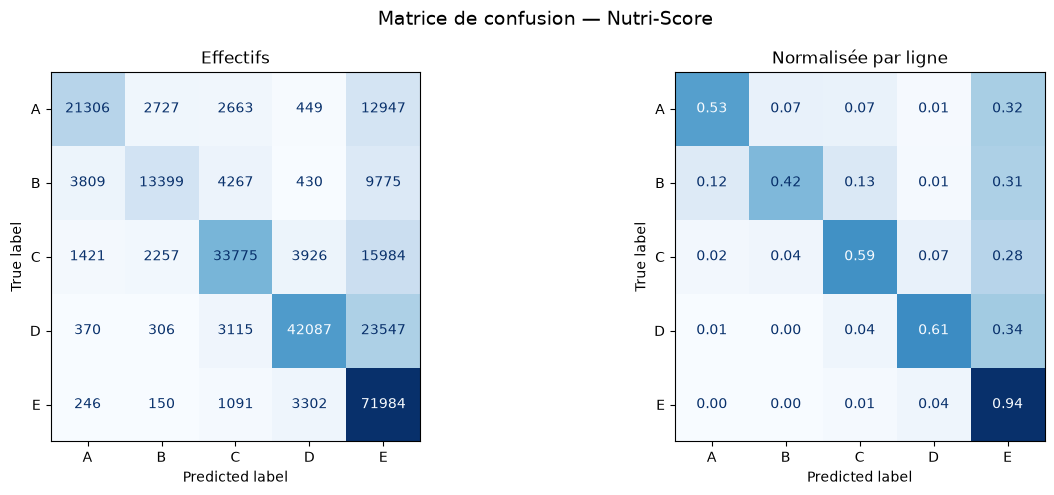

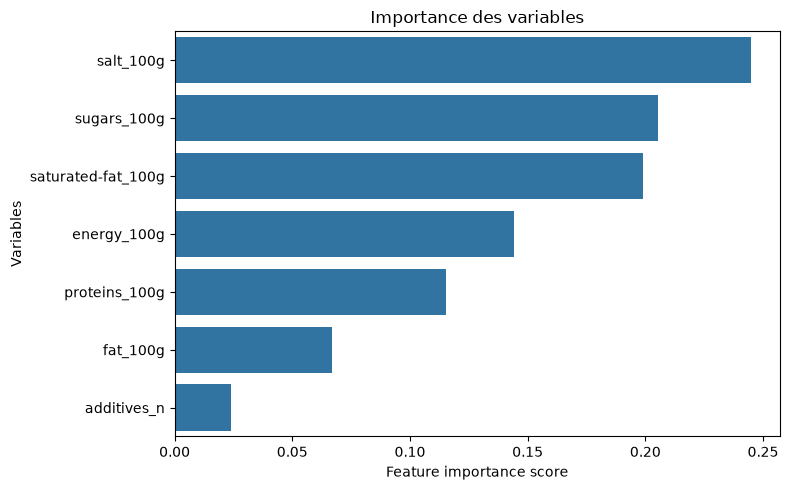

salt_100g             0.244959
sugars_100g           0.205455
saturated-fat_100g    0.198796
energy_100g           0.144322
proteins_100g         0.115343
fat_100g              0.067029
additives_n           0.024095
dtype: float64


In [ ]:
# ============================================================
#  5. ÉVALUATION du meilleur modèle  (ton code, inchangé)
# ============================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
 
best_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1, class_weight="balanced")
best_model.fit(X_train, y_train)
 
y_pred = best_model.predict(X_test)
 
print(classification_report(y_test, y_pred))
print(f"Accuracy test : {best_model.score(X_test, y_test):.4f}")
 
 
# --- Matrice de confusion ---
labels = sorted(y_train.unique())
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Effectifs")
 
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", normalize="true", values_format=".2f",
    ax=axes[1], colorbar=False
)
axes[1].set_title("Normalisée par ligne")
 
fig.suptitle("Matrice de confusion — Nutri-Score", fontsize=14)
plt.tight_layout()
plt.show()
 
 
# --- Importance des variables ---
feature_scores = pd.Series(best_model.feature_importances_,
                           index=X_train.columns).sort_values(ascending=False)
 
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel("Feature importance score")
plt.ylabel("Variables")
plt.title("Importance des variables")
plt.tight_layout()
plt.show()
 
print(feature_scores)
 
 
# --- Graphiques Optuna ---
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_parallel_coordinate(study).show()


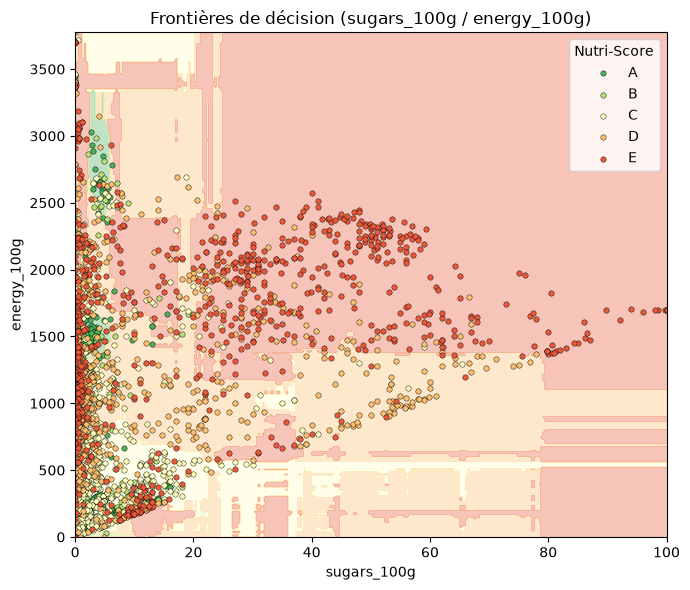

In [5]:
 
# --- Frontières de décision (ton code, inchangé) ---
from matplotlib.colors import ListedColormap
 
def plot_decision_regions(X_df, y_ser, classifier,
                          features=("sugars_100g", "energy_100g"),
                          figsize=(7, 6), n_grid=300, sample=3000):
    f0, f1 = features
    d = pd.concat([X_df[[f0, f1]], y_ser], axis=1)
    if len(d) > sample:
        d = d.sample(sample, random_state=42)
    X2, y2 = d[[f0, f1]], d[y_ser.name]
 
    classes = sorted(y2.unique())
    idx = {c: i for i, c in enumerate(classes)}
 
    clf = classifier.fit(X2, y2)
 
    x_min, x_max = X2[f0].min(), X2[f0].max()
    y_min, y_max = X2[f1].min(), X2[f1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid),
                         np.linspace(y_min, y_max, n_grid))
 
    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[f0, f1])
    Z = pd.Series(clf.predict(grid)).map(idx).values.reshape(xx.shape)
 
    cmap = ListedColormap(sns.color_palette("RdYlGn_r", len(classes)).as_hex())
 
    fig, ax = plt.subplots(figsize=figsize)
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.35, levels=np.arange(-0.5, len(classes)))
 
    for c in classes:
        m = y2 == c
        ax.scatter(X2.loc[m, f0], X2.loc[m, f1], color=cmap(idx[c]),
                   label=c.upper(), edgecolor="black", linewidth=0.3, s=15)
 
    ax.set_xlabel(f0)
    ax.set_ylabel(f1)
    ax.set_title(f"Frontières de décision ({f0} / {f1})")
    ax.legend(title="Nutri-Score")
    plt.tight_layout()
    plt.show()
 
plot_decision_regions(
    X_train, y_train,
    RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
)

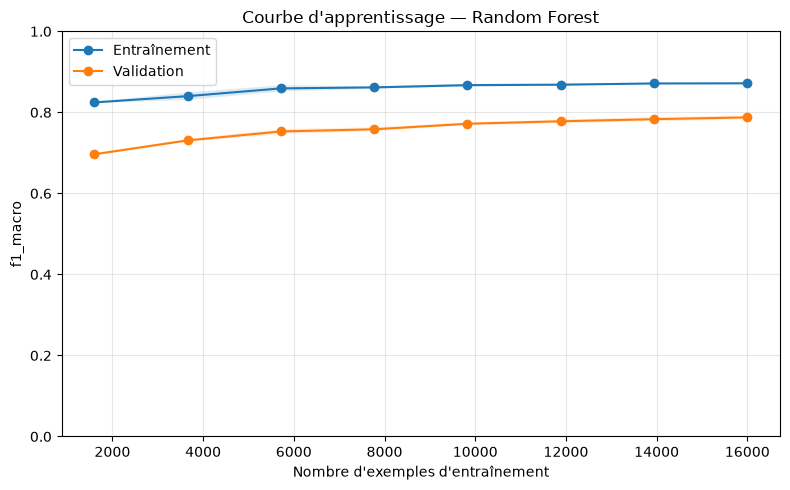

X_train : 20000
X_test  : 275333


In [6]:
# --- Courbe d'apprentissage (ton code, inchangé) ---
from sklearn.model_selection import learning_curve
 
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring="f1_macro", n_jobs=-1, random_state=42
)
 
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)
 
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Entraînement")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, "o-", label="Validation")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("f1_macro")
plt.ylim(0, 1)   # force l'axe vertical de 0 à 1
plt.title("Courbe d'apprentissage — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
print("X_train :", len(X_train))
print("X_test  :", len(X_test))


In [7]:
# ============================================================
#  6. PRÉDICTION sur le dataset INCONNU (le but final)
# ============================================================
print("Aliments à prédire (inconnu) :", X_inconnu.shape)
 
# on prédit le nutriscore des aliments qui n'en avaient pas
predictions_inconnu = best_model.predict(X_inconnu)
 
X_inconnu_avec_pred = X_inconnu.copy()
X_inconnu_avec_pred["nutriscore_predit"] = predictions_inconnu
 
print("\nRépartition des nutriscores prédits :")
print(X_inconnu_avec_pred["nutriscore_predit"].value_counts())
 
X_inconnu_avec_pred.head(10)


Aliments à prédire (inconnu) : (1538679, 7)

Répartition des nutriscores prédits :
nutriscore_predit
e    615931
d    418261
c    272641
a    129032
b    102814
Name: count, dtype: int64


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,additives_n,nutriscore_predit
1,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,0.0,e
4,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,2.0,e
12,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,3.0,e
15,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,0.0,e
16,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,2.0,e
19,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,0.0,e
20,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,0.0,e
22,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,0.0,e
23,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,4.0,e
24,1175.762,5.510514,13228.603518,1.795091,4880.904673,15.020009,1.0,e


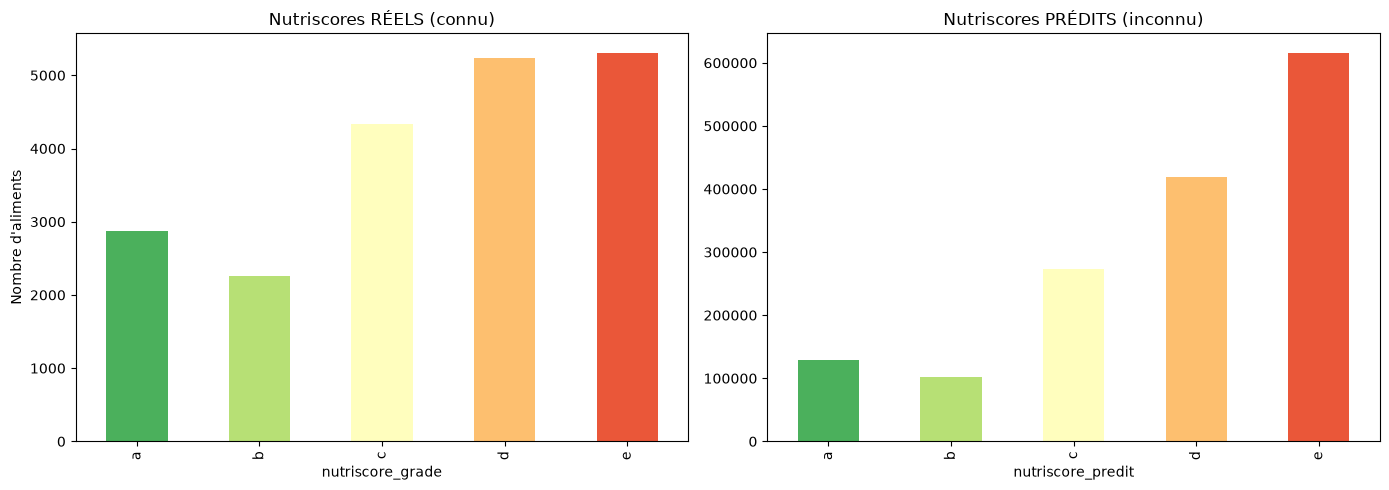

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# notes réelles (connu)
y_train.value_counts().sort_index().plot(kind="bar", ax=axes[0],
    color=sns.color_palette("RdYlGn_r", 5))
axes[0].set_title("Nutriscores RÉELS (connu)")
axes[0].set_ylabel("Nombre d'aliments")

# notes prédites (inconnu)
X_inconnu_avec_pred["nutriscore_predit"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=sns.color_palette("RdYlGn_r", 5))
axes[1].set_title("Nutriscores PRÉDITS (inconnu)")

plt.tight_layout()
plt.show()